## CNN for Parking Space Classification

### Import Libraries

In [25]:
from pathlib import Path

import keras_tuner as kt
import matplotlib.pyplot as plt
import numpy as np
import tensorboard
import tensorflow as tf
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from tensorflow.keras import layers

### Load and Split the Dataset: 70% Training, 15% Validation, and 15% Test

In [26]:
DATASET_DIR = Path("dataset")
CLASS_FOLDERS = ["0_Parqueo", "1_Parqueo"]
DISPLAY_CLASS_NAMES = ["Free", "Occupied"]
IMG_SIZE = (128, 128)
BATCH_SIZE = 16
SEED = 43

full_dataset = tf.keras.utils.image_dataset_from_directory(
    DATASET_DIR,
    labels="inferred",
    label_mode="binary",
    class_names=CLASS_FOLDERS,
    image_size=IMG_SIZE,
    batch_size=None,
    shuffle=False,
)

total_images = tf.data.experimental.cardinality(full_dataset).numpy()

full_dataset = full_dataset.shuffle(
    total_images,
    seed=SEED,
    reshuffle_each_iteration=False,
)

train_count = int(total_images * 0.70)
remaining_count = total_images - train_count
validation_count = remaining_count // 2
test_count = remaining_count - validation_count

train_raw = full_dataset.take(train_count)
remaining_dataset = full_dataset.skip(train_count)
validation_raw = remaining_dataset.take(validation_count)
test_raw = remaining_dataset.skip(validation_count)

AUTOTUNE = tf.data.AUTOTUNE
train_ds = (
    train_raw
    .cache()
    .shuffle(train_count, seed=SEED)
    .batch(BATCH_SIZE)
    .prefetch(AUTOTUNE)
)
validation_ds = validation_raw.cache().batch(BATCH_SIZE).prefetch(AUTOTUNE)
test_ds = test_raw.cache().batch(BATCH_SIZE).prefetch(AUTOTUNE)

print(f"Total: {total_images}")
print(f"Training: {train_count} ({train_count / total_images:.1%})")
print(f"Validation: {validation_count} ({validation_count / total_images:.1%})")
print(f"Test: {test_count} ({test_count / total_images:.1%})")

Found 250 files belonging to 2 classes.
Total: 250
Training: 175 (70.0%)
Validation: 37 (14.8%)
Test: 38 (15.2%)


### Data Augmentation
These transformations run only during training because they are included inside the CNN.

In [27]:
def create_data_augmentation():
    return tf.keras.Sequential(
        [
            layers.RandomFlip("horizontal"),
            layers.RandomRotation(0.05),
            layers.RandomZoom(0.20),
            layers.RandomContrast(0.20),
        ],
        name="data_augmentation",
    )

data_augmentation = create_data_augmentation()

### CNN Model and Hyperparameter Search Space

In [28]:
def build_model(hp):
    input_layer = layers.Input(
        shape=(IMG_SIZE[0], IMG_SIZE[1], 3),
        name="input_image",
    )

    x = create_data_augmentation()(input_layer)
    x = layers.Rescaling(1.0 / 255, name="normalization")(x)

    x = layers.Conv2D(32, (3, 3), activation="relu")(x)
    x = layers.MaxPooling2D((2, 2))(x)
    x = layers.Conv2D(64, (3, 3), activation="relu")(x)
    x = layers.MaxPooling2D((2, 2))(x)
    x = layers.Conv2D(128, (3, 3), activation="relu")(x)
    x = layers.Flatten()(x)

    num_dense_layers = hp.Int("num_dense_layers", min_value=1, max_value=3)
    for index in range(num_dense_layers):
        units = hp.Choice(
            f"dense_units_{index + 1}",
            values=[32, 64, 128, 256],
        )
        x = layers.Dense(units, activation="relu")(x)

    output_layer = layers.Dense(1, activation="sigmoid", name="output")(x)
    model = tf.keras.Model(inputs=input_layer, outputs=output_layer)

    learning_rate = hp.Choice(
        "learning_rate",
        values=[1e-2, 1e-3, 1e-4],
    )

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
        loss="binary_crossentropy",
        metrics=["accuracy"],
    )

    return model

### Random Search with Keras Tuner

In [29]:
tuner = kt.RandomSearch(
    hypermodel=build_model,
    objective=kt.Objective("val_accuracy", direction="max"),
    max_trials=10,
    executions_per_trial=1,
    directory="keras_tuner_results",
    project_name="parking_lot_cnn",
    overwrite=True,
    seed=SEED,
)

tuner.search_space_summary()

tuner_early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True,
)

tuner.search(
    train_ds,
    validation_data=validation_ds,
    epochs=15,
    callbacks=[tuner_early_stopping],
    shuffle=False,
    verbose=1,
)

Trial 10 Complete [00h 00m 05s]
val_accuracy: 0.9729729890823364

Best val_accuracy So Far: 1.0
Total elapsed time: 00h 00m 48s


### Build and Train the Best Model

In [30]:
best_hp = tuner.get_best_hyperparameters(num_trials=1)[0]

print("Best hyperparameters:")
print("Learning rate:", best_hp.get("learning_rate"))
print("Number of Dense layers:", best_hp.get("num_dense_layers"))
for index in range(best_hp.get("num_dense_layers")):
    print(
        f"Dense layer {index + 1} units:",
        best_hp.get(f"dense_units_{index + 1}"),
    )

best_model = tuner.hypermodel.build(best_hp)

final_early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True,
)

history = best_model.fit(
    train_ds,
    validation_data=validation_ds,
    epochs=30,
    callbacks=[final_early_stopping],
    shuffle=False,
    verbose=1,
)

best_model.summary()

Best hyperparameters:
Learning rate: 0.0001
Number of Dense layers: 3
Dense layer 1 units: 32
Dense layer 2 units: 32
Dense layer 3 units: 128


Epoch 1/30
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 43ms/step - accuracy: 0.4800 - loss: 0.6997 - val_accuracy: 0.5405 - val_loss: 0.6797
Epoch 2/30
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - accuracy: 0.5257 - loss: 0.6689 - val_accuracy: 0.5405 - val_loss: 0.6302
Epoch 3/30
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - accuracy: 0.7143 - loss: 0.6078 - val_accuracy: 0.8649 - val_loss: 0.5317
Epoch 4/30
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - accuracy: 0.8971 - loss: 0.4769 - val_accuracy: 0.9459 - val_loss: 0.3618
Epoch 5/30
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - accuracy: 0.9314 - loss: 0.3146 - val_accuracy: 0.9459 - val_loss: 0.2136
Epoch 6/30
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - accuracy: 0.9600 - loss: 0.1751 - val_accuracy: 1.0000 - val_loss: 0.1079
Epoch 7/30
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - accuracy: 0.9657 - loss: 0.1208 - val_accuracy: 0.9459 - val_loss: 0.0908
Epoch 8/30
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - accuracy: 0.9543 - loss: 0.1006 - val_accuracy: 0.9459 - v

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_image (InputLayer)        │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ normalization (Rescaling)       │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 100352)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 32)             │     3,211,296 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 128)            │         4,224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9,929,861 (37.88 MB)

 Trainable params: 3,309,953 (12.63 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 6,619,908 (25.25 MB)

### Training Curves for the Best Model

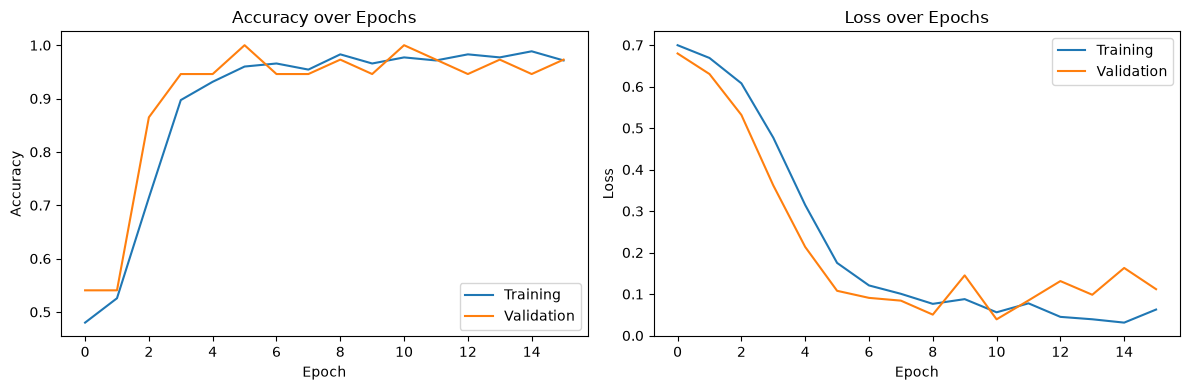

In [31]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history["accuracy"], label="Training")
plt.plot(history.history["val_accuracy"], label="Validation")
plt.title("Accuracy over Epochs")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history["loss"], label="Training")
plt.plot(history.history["val_loss"], label="Validation")
plt.title("Loss over Epochs")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.tight_layout()
plt.show()

### Final Evaluation on the Test Set

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9737 - loss: 0.0365 
Test loss: 0.0365
Test accuracy: 0.9737


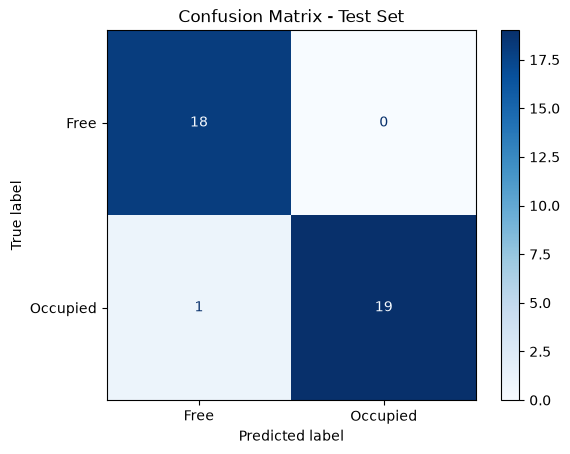

              precision    recall  f1-score   support

        Free       0.95      1.00      0.97        18
    Occupied       1.00      0.95      0.97        20

    accuracy                           0.97        38
   macro avg       0.97      0.97      0.97        38
weighted avg       0.98      0.97      0.97        38



In [32]:
test_loss, test_accuracy = best_model.evaluate(test_ds, verbose=1)
print(f"Test loss: {test_loss:.4f}")
print(f"Test accuracy: {test_accuracy:.4f}")

prediction_probabilities = best_model.predict(test_ds, verbose=0).ravel()
predicted_labels = (prediction_probabilities >= 0.5).astype(int)
true_labels = np.concatenate(
    [labels.numpy().ravel() for _, labels in test_ds]
).astype(int)

confusion = confusion_matrix(true_labels, predicted_labels, labels=[0, 1])
display = ConfusionMatrixDisplay(
    confusion_matrix=confusion,
    display_labels=DISPLAY_CLASS_NAMES,
)
display.plot(cmap="Blues", values_format="d")
plt.title("Confusion Matrix - Test Set")
plt.show()

print(
    classification_report(
        true_labels,
        predicted_labels,
        labels=[0, 1],
        target_names=DISPLAY_CLASS_NAMES,
        zero_division=0,
    )
)